`conda activate imgpro`

In [8]:
import importlib, sys
import numpy as np
import os, glob, h5py
import matplotlib.pyplot as plt
import utils
import wavelet_utils as wu
import pandas as pd

utils.default_plt_params()
%matplotlib inline

---
## 1. Load a single SWF415 recording

In [2]:
data_pth = r'C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id'
uid = '2022-04-12-02-data.h5'
path_h5 = os.path.join(data_pth, uid)

with h5py.File(path_h5, 'r') as h5f:
    data = utils.h5_to_dict(h5f)

# Sampling
volume_rate = 1.7          # volumes / s
dt = 1.0 / volume_rate     # seconds / frame
food_idx = int(data['timing']['time_food_encounter'])
print(f'Loaded {uid}  |  {data["gcamp"]["trace_array"].shape[0]} frames  |  food @ frame {food_idx}')

Loaded 2022-04-12-02-data.h5  |  1600 frames  |  food @ frame 665


---
## 2. Visualise raw NSM traces

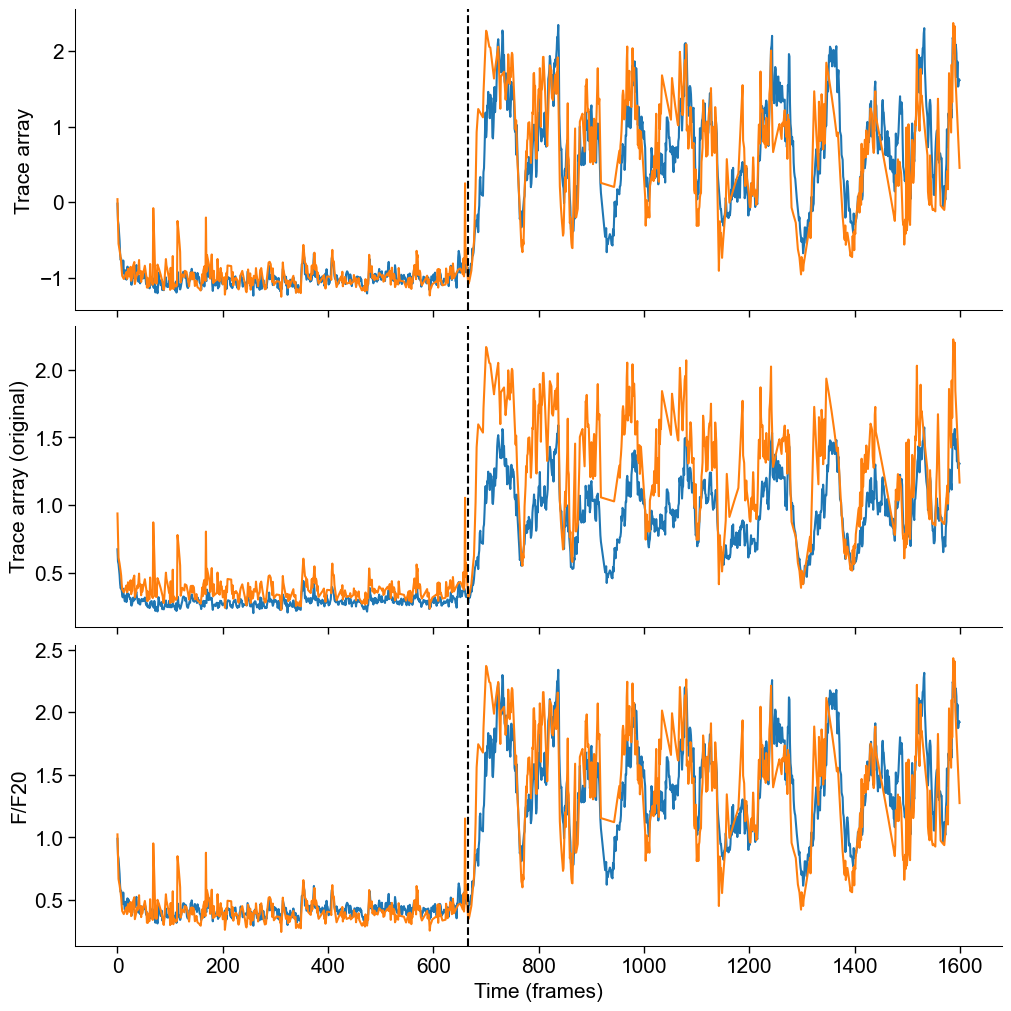

In [3]:
trace_keys = ['trace_array', 'trace_array_original', 'traces_array_F_F20']
titles = ['Trace array', 'Trace array (original)', 'F/F20']

nsm_idx = data['gcamp']['idx_nsm']
fig, axes, nt = utils.pretty_subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=True)

for tk, title in zip(trace_keys, titles):
    ax = nt()
    if hasattr(nsm_idx, '__len__') and len(nsm_idx) > 1:
        for j in range(len(nsm_idx)):
            ax.plot(data['gcamp'][tk][:, nsm_idx[j] - 1], label=f'NSM {j+1}')
    else:
        ax.plot(data['gcamp'][tk][:, int(nsm_idx) - 1], label='NSM')
    ax.axvline(food_idx, color='black', ls='--')
    ax.set_ylabel(title)

plt.xlabel('Time (frames)')
plt.show()

---
## 3. GSTV denoising

In [ ]:
# Extract NSM trace
raw = wu.get_nsm_trace(data, 'trace_array')[:, None]   # (n_time, 1)

smooth_traces, interp_traces = wu.smooth_neural_data_gstv(raw, k=100, lam=0.025)

fig, axes, nt = utils.pretty_subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True)

ax0 = nt()
ax0.plot(raw[:, 0], 'k', lw=0.5, alpha=0.6)
ax0.set_ylabel('z-scored'); ax0.set_title('Raw')

ax1 = nt()
ax1.plot(interp_traces[:, 0], 'steelblue', lw=0.8)
ax1.set_ylabel('z-scored'); ax1.set_title('Interpolated (mild GSTV)')

ax2 = nt()
ax2.plot(smooth_traces[:, 0], 'darkorange', lw=0.8)
ax2.set_ylabel('z-scored'); ax2.set_xlabel('Frame')
ax2.set_title('Smoothed (GSTV k=100, λ=0.025)')

plt.show()

---
## 4. Causal normalise → smooth → derivative pipeline

In [ ]:
nsm_raw = wu.get_nsm_trace(data, 'traces_array_F_F20')
time_axis = np.arange(len(nsm_raw)) * dt

normalized, smoothed, derivative = wu.normalize_smooth_derivative(
    nsm_raw, dt, sigma_seconds=3.0, causal=True
)

fig, axes, nt = utils.pretty_subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True)

nt().plot(time_axis, normalized, 'k', lw=0.5)
axes[0, 0].set_ylabel('[0, 1]'); axes[0, 0].set_title('Min-max normalised')

nt().plot(time_axis, smoothed, 'steelblue', lw=1)
axes[1, 0].set_ylabel('Smoothed'); axes[1, 0].set_title('Causal EMA (σ = 3 s)')

ax2 = nt()
ax2.plot(time_axis, derivative, 'darkorange', lw=0.8)
ax2.axhline(0, color='grey', lw=0.5, ls='--')
ax2.set_ylabel('d/dt (1/s)'); ax2.set_xlabel('Time (s)')
ax2.set_title('First derivative')

plt.show()

---
## 5. Automatic bandpass cutoff selection (PSD-based)

The PSD of the (pre-processed) signal is computed via Welch's method.
The dominant oscillation band is detected by walking outward from the
spectral peak until the power drops −6 dB.  A safety margin (1.5×)
is applied in log-frequency space so the bandpass does not clip the
signal of interest.

In [ ]:
# Pre-process: min-max normalise + GSTV denoise
nsm_trace = wu.minmax_normalize(wu.get_nsm_trace(data, 'trace_array'))
nsm_smooth, _ = wu.smooth_neural_data_gstv(nsm_trace.reshape(-1, 1))
nsm_smooth = nsm_smooth[:, 0]

fs = volume_rate   # Hz

# --- Automatic cutoff detection ---
low_hz, high_hz, info = wu.auto_bandpass_cutoffs(nsm_smooth, fs,
                                                  threshold_db=-10,
                                                  margin_factor=4.0)
print(f'Recommended bandpass: {low_hz:.5f} – {high_hz:.5f} Hz')
print(f'Peak frequency:       {info["f_peak"]:.5f} Hz')
print(f'Peak SNR:             {info["snr_db"]:.1f} dB')

# --- Diagnostic plots ---
fig, axs = plt.subplots(1, 2, figsize=(14, 3.5))

# PSD + cutoffs
wu.plot_psd_with_cutoffs(info, low_hz, high_hz, ax=axs[0])

# Filter magnitude response
from scipy import signal as _sig
sos = _sig.butter(4, [low_hz, high_hz], btype='band', fs=fs, output='sos')
wu.plot_filter_response(sos, fs, ax=axs[1])

plt.tight_layout()
plt.show()

---
## 6. Causal bandpass filtering + wavelet spectrogram (single recording)

In [ ]:
# Apply causal bandpass on the FULL signal (avoids edge effects at food_idx),
# then trim to post-encounter for all analysis and plotting.

nsm_bp_full = wu.causal_bandpass(nsm_smooth, low_hz, high_hz, fs, order=4)

# --- Trim to post-encounter ---
nsm_bp = nsm_bp_full[food_idx:]
time_axis = np.arange(len(nsm_bp)) * dt  # time relative to encounter start

# Wavelet spectrum (post-encounter only)
freqs = np.linspace(0.0001, 0.2, 500)
W = wu.wavelet_spectrum(nsm_bp, freqs, dt, ksi=4.0)

# --- Spectrogram ---
fig, axes, nt = utils.pretty_subplots(nrows=2, ncols=1, figsize=(10, 4), sharex=True)

ax0 = nt()
ax0.plot(time_axis, nsm_bp, 'k', lw=0.8)
ax0.set_ylabel('Bandpassed NSM')

ax1 = nt()
im = ax1.pcolormesh(time_axis, freqs, np.abs(W).T, shading='auto', cmap='YlOrBr')
ax1.set_ylabel('Freq (Hz)'); ax1.set_xlabel('Time since encounter (s)')
fig.colorbar(im, ax=ax1, label='Amp. (a.u.)')
plt.show()

# --- Time-averaged spectrum (all post-encounter) ---
avg_spec = wu.time_averaged_spectrum(W)
fig, ax = utils.pretty_plot(figsize=(2.4, 4.5))
ax.plot(avg_spec, freqs, 'k', lw=1.5)
ax.set_xscale('log')
ax.set_xlabel('Amp. (a.u.)'); ax.set_ylabel('Freq (Hz)')
plt.tight_layout(); plt.show()

---
## 7. Cycle-phase detection: rising & falling segments

After bandpass filtering the signal consists mainly of the dominant
oscillation, so peak / trough detection is reliable.  Each trough→peak
interval is labelled **rising** (green) and each peak→trough interval
**falling** (red).

In [ ]:
# Use the post-food segment for cleaner oscillations
t_post = time_axis[food_idx:]
sig_post = nsm_bp[food_idx:]

# Detect cycles
# min_peak_distance_sec should be ~half the expected period
expected_period = 0.2 / info['f_peak']   # seconds
cycles = wu.find_oscillation_cycles(
    sig_post, fs,
    min_peak_distance_sec=expected_period * 0.4,
    peak_prominence=0.05 * np.std(sig_post),
)

n_peaks = len(cycles['peaks'])
n_troughs = len(cycles['troughs'])
print(f'Detected {n_peaks} peaks, {n_troughs} troughs')
print(f'Rising segments:  {len(cycles["rising"])}')
print(f'Falling segments: {len(cycles["falling"])}')

# --- Plot with shaded phases ---
fig, axes, nt = utils.pretty_subplots(nrows=2, ncols=1, figsize=(12, 5), sharex=True)

wu.plot_cycles(t_post, sig_post, cycles, ax=nt(),
               title='Bandpassed NSM – rising / falling phases')

wu.plot_instantaneous_phase(t_post, cycles['inst_phase'], ax=nt(),
                            title='')

plt.xlabel('Time (s)')
plt.show()

---
## 8. Cycle statistics

In [ ]:
# Duration of rising / falling half-cycles
rising_dur  = [(b - a) * dt for a, b in cycles['rising']]
falling_dur = [(b - a) * dt for a, b in cycles['falling']]

# Amplitude of each half-cycle
rising_amp  = [sig_post[b] - sig_post[a] for a, b in cycles['rising']]
falling_amp = [sig_post[a] - sig_post[b] for a, b in cycles['falling']]

fig, axes, nt = utils.pretty_subplots(nrows=1, ncols=2, figsize=(8, 3.5))

# plot scatter and boxplot for rising vs falling durations and amplitudes
ax0 = nt()
ax0.scatter(np.ones(len(rising_dur))-1, rising_dur, color='#2ca02c', alpha=0.6, label='Rising')
ax0.scatter(np.ones(len(falling_dur)), falling_dur, color='#d62728', alpha=0.6, label='Falling')
ax0.bar(['Rising', 'Falling'],
        [np.mean(rising_dur), np.mean(falling_dur)],
        yerr=[np.std(rising_dur), np.std(falling_dur)],
        color=['#2ca02c', '#d62728'], capsize=5)
ax0.set_ylabel('Duration (s)')
ax0.set_title('Half-cycle durations')

ax1 = nt()
ax1.bar(['Rising', 'Falling'],
        [np.mean(rising_amp), np.mean(falling_amp)],
        yerr=[np.std(rising_amp), np.std(falling_amp)],
        color=['#2ca02c', '#d62728'], capsize=5)
ax1.set_ylabel('Amplitude (a.u.)')
ax1.set_title('Half-cycle amplitudes')

plt.tight_layout(); plt.show()

print(f'Rising  duration: {np.mean(rising_dur):.1f} ± {np.std(rising_dur):.1f} s')
print(f'Falling duration: {np.mean(falling_dur):.1f} ± {np.std(falling_dur):.1f} s')
print(f'Rising  amplitude: {np.mean(rising_amp):.4f} ± {np.std(rising_amp):.4f}')
print(f'Falling amplitude: {np.mean(falling_amp):.4f} ± {np.std(falling_amp):.4f}')

---
## 9. Batch analysis across all SWF415 recordings


=== Processing swf415_no_id ===
  [1/7] 2022-01-16-01-data.h5
  neuron 1/1
0.008333333333333333 0.0625


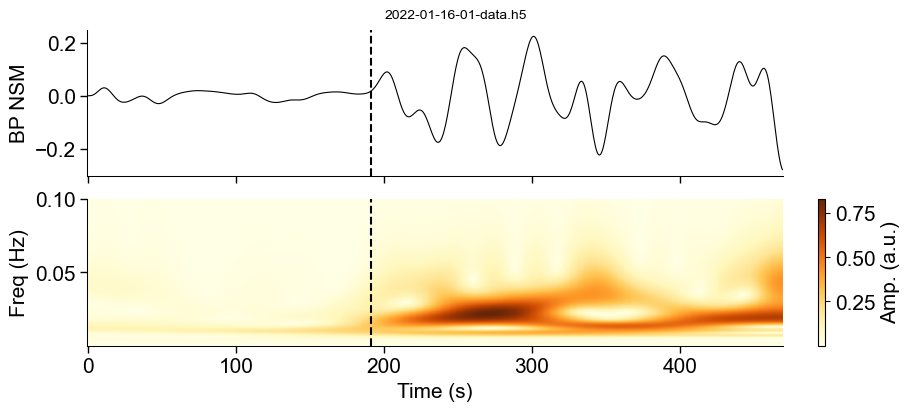

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:92: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


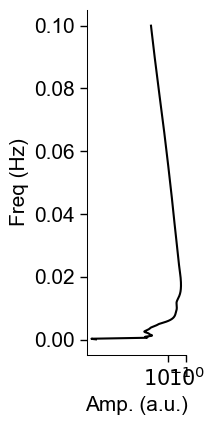

  [2/7] 2022-01-25-01-data.h5
  neuron 1/1
0.008333333333333333 0.05


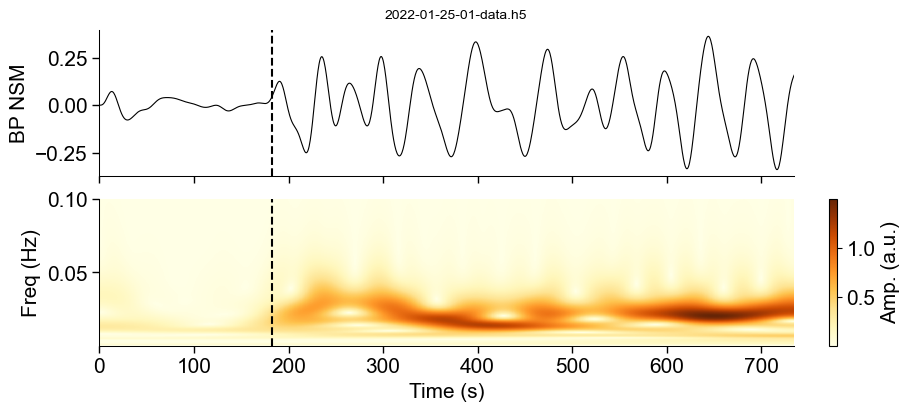

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:92: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


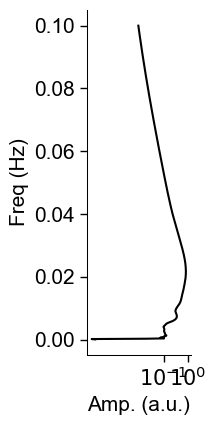

  [3/7] 2022-03-17-01-data.h5
  neuron 1/1
0.008333333333333333 0.037500000000000006


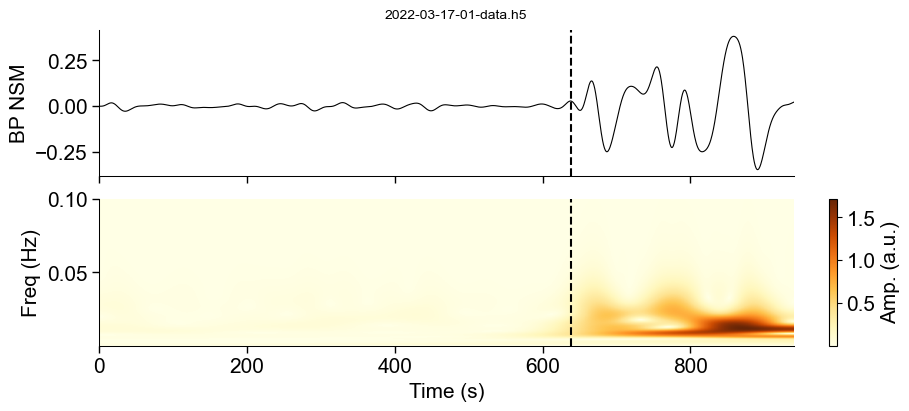

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:92: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


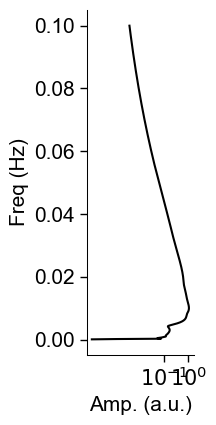

  [4/7] 2022-03-25-03-data.h5
  neuron 1/1
0.008333333333333333 0.05


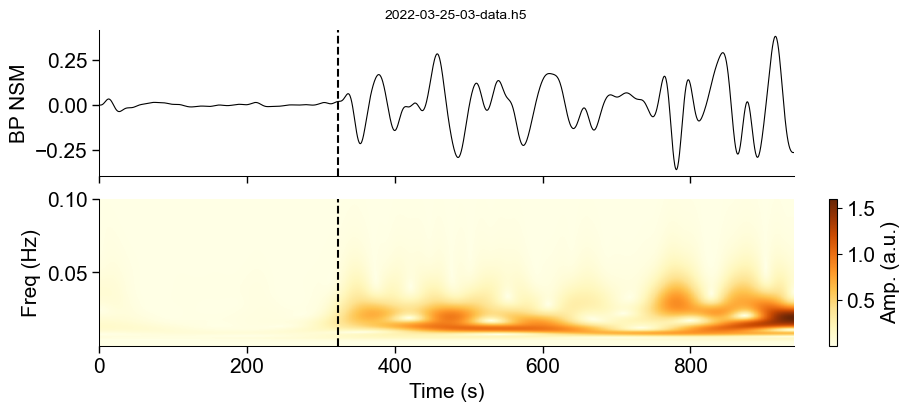

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:92: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


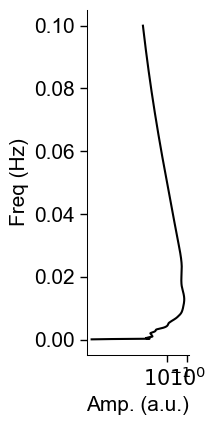

  [5/7] 2022-04-05-01-data.h5
  neuron 1/1
0.008333333333333333 0.037500000000000006


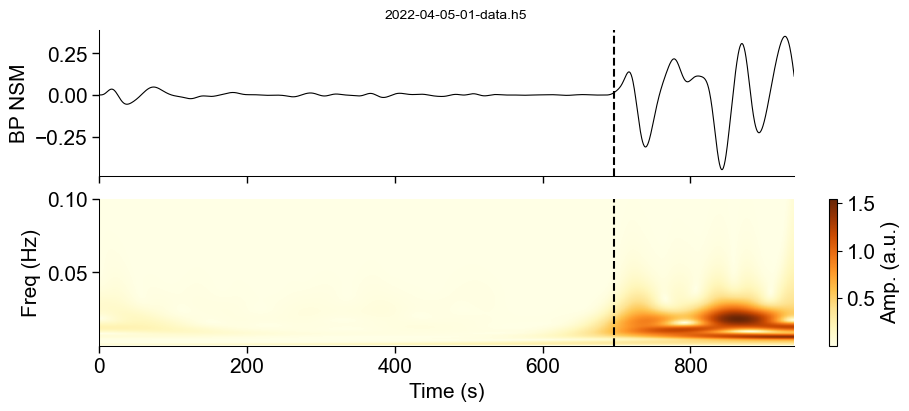

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:92: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


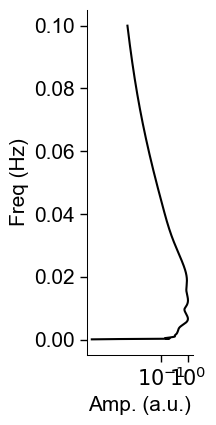

  [6/7] 2022-04-12-02-data.h5
  neuron 1/1
0.008333333333333333 0.05


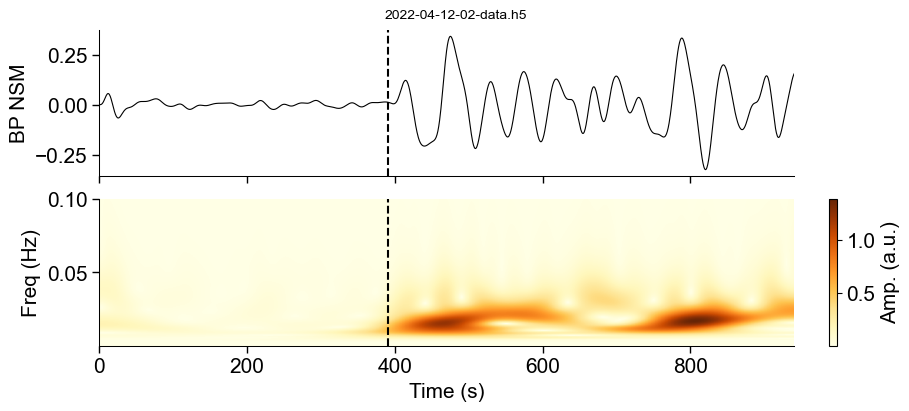

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:92: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


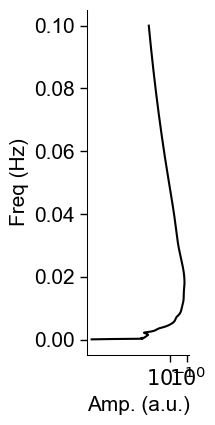

  [7/7] 2022-05-02-01-data.h5
  neuron 1/1
0.008333333333333333 0.037500000000000006


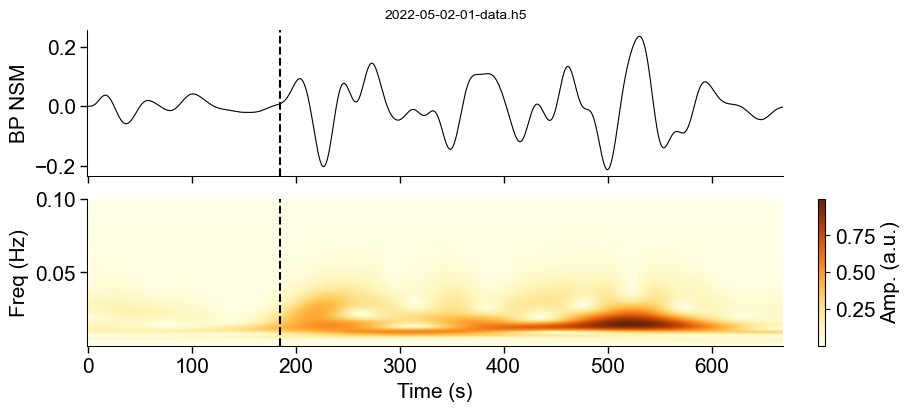

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:92: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


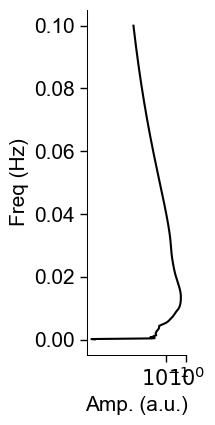

In [11]:
data_pth = r'C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024'
swf_pth = ['swf415_no_id']
trace_key = 'trace_array'
freqs = np.linspace(0.0001, 0.1, 1000)

plt.close('all')

for swf in swf_pth:
    print(f'\n=== Processing {swf} ===')
    swf_dir = os.path.join(data_pth, swf)
    h5_files = sorted(glob.glob(os.path.join(swf_dir, '*.h5')))

    amp_recordings = np.full((len(h5_files), len(freqs)), np.nan)

    for i, h5_file in enumerate(h5_files):
        print(f'  [{i+1}/{len(h5_files)}] {os.path.basename(h5_file)}')
        with h5py.File(h5_file, 'r') as h5f:
            rec = utils.h5_to_dict(h5f)

        nsm_trace = wu.get_nsm_trace(rec, trace_key)
        nsm_trace = wu.minmax_normalize(nsm_trace)
        nsm_smooth, _ = wu.smooth_neural_data_gstv(nsm_trace.reshape(-1, 1))
        nsm_smooth = nsm_smooth[:, 0]

        fs_rec = volume_rate
        dt_rec = 1.0 / fs_rec

        # Auto bandpass
        lo, hi, bp_info = wu.auto_bandpass_cutoffs(nsm_smooth, fs_rec,
                                                   threshold_db=-6,
                                                   margin_factor=1.5)
        print(lo, hi)
        nsm_bp = wu.causal_bandpass(nsm_smooth, lo, hi, fs_rec, order=4)

        # Wavelet spectrum
        W = wu.wavelet_spectrum(nsm_bp, freqs, dt_rec, ksi=4.0)

        # --- Spectrogram ---
        time_ax = np.arange(len(nsm_bp)) * dt_rec
        fig, axes, nt = utils.pretty_subplots(nrows=2, ncols=1, figsize=(9, 4), sharex=True)

        ax0 = nt()
        ax0.plot(time_ax, nsm_bp, 'k', lw=0.8)
        food_idx_rec = int(rec['timing']['time_food_encounter'])
        ax0.axvline(food_idx_rec * dt_rec, color='black', ls='--')
        ax0.set_ylabel('BP NSM')

        ax1 = nt()
        im = ax1.pcolormesh(time_ax, freqs, np.abs(W).T, shading='auto', cmap='YlOrBr')
        ax1.axvline(food_idx_rec * dt_rec, color='black', ls='--')
        ax1.set_ylabel('Freq (Hz)'); ax1.set_xlabel('Time (s)')
        fig.colorbar(im, ax=ax1, label='Amp. (a.u.)')
        fig.suptitle(os.path.basename(h5_file), fontsize=10)
        plt.show()

        # Time-averaged spectrum
        avg_spec = wu.time_averaged_spectrum(W, start_idx=food_idx_rec)

        fig, ax = utils.pretty_plot(figsize=(2.4, 4.5))
        ax.plot(avg_spec, freqs, 'k', lw=1.5)
        ax.set_xscale('log')
        ax.set_xlabel('Amp. (a.u.)'); ax.set_ylabel('Freq (Hz)')
        ax.set_xticks([1e-1, 1e0])
        ax.set_xticklabels([r'$10^{-1}$', r'$10^{0}$'])
        plt.tight_layout(); plt.show()

        amp_recordings[i, :] = avg_spec

In [6]:
# Peak frequencies
%matplotlib qt
peak_freqs = freqs[np.argmax(amp_recordings, axis=1)]
print('Peak frequencies:', peak_freqs)

# Summary plot
fig, ax = utils.pretty_plot(figsize=(5, 4))
for j in range(amp_recordings.shape[0]):
    ax.plot(freqs, amp_recordings[j, :], 'k', lw=0.8, alpha=0.5)
ax.plot(freqs, np.nanmean(amp_recordings, axis=0), 'red', lw=2, label='mean')
ax.set_xscale('log')
ax.set_xlabel('Freq (Hz)'); ax.set_ylabel('Amp (a.u.)')
ax.legend()
plt.tight_layout(); plt.show()

Peak frequencies: [0.0174 0.0216 0.0101 0.0128 0.0125 0.0182 0.0133]


c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:92: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


  neuron 1/1
  neuron 1/1
  neuron 1/1
  neuron 1/1
  neuron 1/1
  neuron 1/1
  neuron 1/1


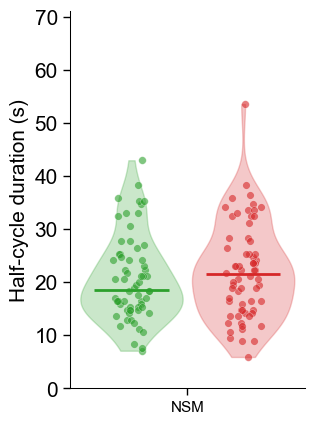

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:92: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


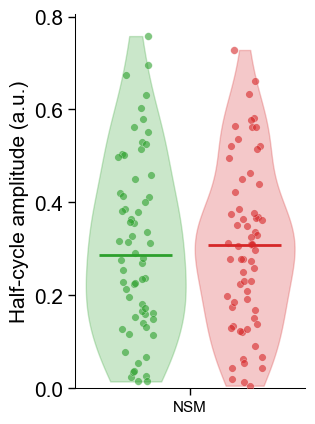

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:92: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


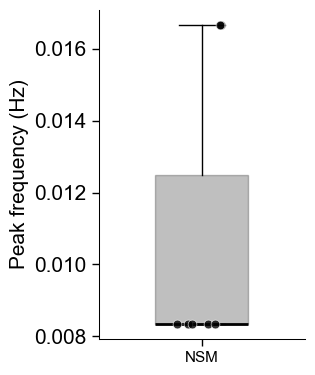

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:92: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


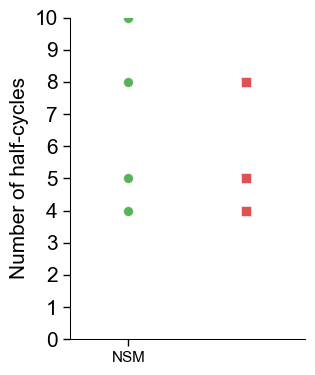

c:\Users\munib\POSTDOC\CODE\Dag_Nwabudike_Kang_2025\utils.py:92: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


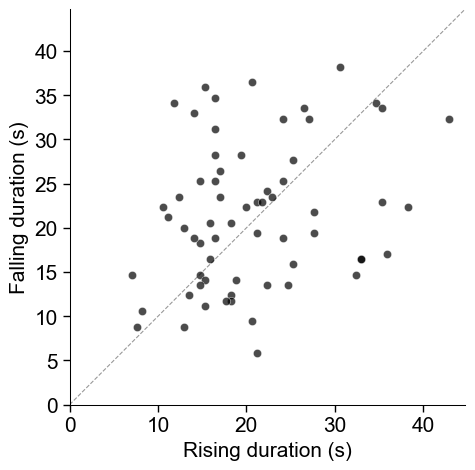

In [10]:
# =====================================================================
#  NSM Summary – same figures as ROI batch summary
# =====================================================================
from matplotlib.patches import Patch
import matplotlib.ticker as mticker

RISE_COL  = '#2ca02c'
FALL_COL  = '#d62728'
NSM_COL   = 'black'

# ---- 1. Collect cycle stats per recording ----
nsm_cycle_rows = []   # long-form: one row per half-cycle
nsm_fpeak_rows = []   # one row per recording
nsm_ncyc_rows  = []   # one row per recording
nsm_paired_rows = []  # one row per paired half-cycle

for i, h5_file in enumerate(h5_files):
    with h5py.File(h5_file, 'r') as h5f:
        rec = utils.h5_to_dict(h5f)

    nsm_t = wu.get_nsm_trace(rec, trace_key)
    nsm_t = wu.minmax_normalize(nsm_t)
    nsm_sm, _ = wu.smooth_neural_data_gstv(nsm_t.reshape(-1, 1))
    nsm_sm = nsm_sm[:, 0]

    lo, hi, bp_info = wu.auto_bandpass_cutoffs(nsm_sm, volume_rate,
                                               threshold_db=-6, margin_factor=1.5)
    nsm_bp_i = wu.causal_bandpass(nsm_sm, lo, hi, volume_rate, order=4)

    fe = int(rec['timing']['time_food_encounter'])
    sig_post = nsm_bp_i[fe:]

    rd, fd, ra, fa = [], [], [], []
    fp = bp_info['f_peak']

    if fp > 0 and len(sig_post) > 0:
        exp_p = 0.2 / fp
        cyc = wu.find_oscillation_cycles(
            sig_post, volume_rate,
            min_peak_distance_sec=exp_p * 0.4,
            peak_prominence=0.05 * np.std(sig_post),
        )
        rd  = [(b - a) * dt for a, b in cyc['rising']]
        fd  = [(b - a) * dt for a, b in cyc['falling']]
        ra  = [sig_post[b] - sig_post[a] for a, b in cyc['rising']]
        fa  = [sig_post[a] - sig_post[b] for a, b in cyc['falling']]

    # long-form rows
    for d in rd:
        nsm_cycle_rows.append(dict(phase='Rising', duration=d, amplitude=np.nan))
    for d in fd:
        nsm_cycle_rows.append(dict(phase='Falling', duration=d, amplitude=np.nan))
    for a in ra:
        nsm_cycle_rows.append(dict(phase='Rising', duration=np.nan, amplitude=a))
    for a in fa:
        nsm_cycle_rows.append(dict(phase='Falling', duration=np.nan, amplitude=a))

    if fp > 0:
        nsm_fpeak_rows.append(dict(f_peak=fp))

    nsm_ncyc_rows.append(dict(n_rising=len(rd), n_falling=len(fd)))

    n_pairs = min(len(rd), len(fd))
    for j in range(n_pairs):
        nsm_paired_rows.append(dict(rise_dur=rd[j], fall_dur=fd[j]))

nsm_cycles_df = pd.DataFrame(nsm_cycle_rows)

# ---- 2. Half-cycle DURATION: violin + strip ----
dur_vals = {ph: nsm_cycles_df.loc[
    (nsm_cycles_df['phase'] == ph) & nsm_cycles_df['duration'].notna(), 'duration'].values
    for ph in ['Rising', 'Falling']}

fig, ax = utils.pretty_plot(figsize=(3.4, 4.5))
pos_r, pos_f = 0.0, 0.6
for phase, pos, pc in [('Rising', pos_r, RISE_COL), ('Falling', pos_f, FALL_COL)]:
    vals = dur_vals[phase]
    if len(vals) == 0:
        continue
    vp = ax.violinplot(vals, positions=[pos], widths=0.55,
                       showmeans=False, showextrema=False, showmedians=False)
    for body in vp['bodies']:
        body.set_facecolor(pc); body.set_alpha(0.25); body.set_edgecolor(pc)
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(vals))
    ax.scatter(pos + jitter, vals, s=30, color=pc, alpha=0.6,
               edgecolors='white', linewidths=0.3, zorder=3)
    ax.hlines(np.median(vals), pos - 0.2, pos + 0.2, color=pc, linewidth=2, zorder=4)

ax.set_xticks([0.3]); ax.set_xticklabels(['NSM'], fontsize=11)
ax.set_ylabel('Half-cycle duration (s)')
ax.set_ylim(0, 71.1022)
plt.tight_layout(); plt.show()

# ---- 3. Half-cycle AMPLITUDE: violin + strip ----
amp_vals = {ph: nsm_cycles_df.loc[
    (nsm_cycles_df['phase'] == ph) & nsm_cycles_df['amplitude'].notna(), 'amplitude'].values
    for ph in ['Rising', 'Falling']}

fig, ax = utils.pretty_plot(figsize=(3.4, 4.5))
for phase, pos, pc in [('Rising', pos_r, RISE_COL), ('Falling', pos_f, FALL_COL)]:
    vals = amp_vals[phase]
    if len(vals) == 0:
        continue
    vp = ax.violinplot(vals, positions=[pos], widths=0.55,
                       showmeans=False, showextrema=False, showmedians=False)
    for body in vp['bodies']:
        body.set_facecolor(pc); body.set_alpha(0.25); body.set_edgecolor(pc)
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(vals))
    ax.scatter(pos + jitter, vals, s=30, color=pc, alpha=0.6,
               edgecolors='white', linewidths=0.3, zorder=3)
    ax.hlines(np.median(vals), pos - 0.2, pos + 0.2, color=pc, linewidth=2, zorder=4)

ax.set_xticks([0.3]); ax.set_xticklabels(['NSM'], fontsize=11)
ax.set_ylabel('Half-cycle amplitude (a.u.)')
ax.set_ylim(0, 0.806201417009056)
plt.tight_layout(); plt.show()

# ---- 4. Peak frequency (scatter + box) ----
if len(nsm_fpeak_rows) > 0:
    fpeak_vals = np.array([r['f_peak'] for r in nsm_fpeak_rows])
    fig, ax = utils.pretty_plot(figsize=(3.4, 4))
    bp = ax.boxplot(fpeak_vals, positions=[0], widths=0.45, patch_artist=True,
                    showfliers=False,
                    boxprops=dict(facecolor=NSM_COL, alpha=0.25, edgecolor=NSM_COL),
                    medianprops=dict(color=NSM_COL, linewidth=2),
                    whiskerprops=dict(color=NSM_COL), capprops=dict(color=NSM_COL))
    jitter = np.random.default_rng(7).uniform(-0.12, 0.12, len(fpeak_vals))
    ax.scatter(0 + jitter, fpeak_vals, s=40, color=NSM_COL, alpha=0.8,
               edgecolors='white', linewidths=0.5, zorder=3)
    ax.set_xticks([0]); ax.set_xticklabels(['NSM'], fontsize=11)
    ax.set_ylabel('Peak frequency (Hz)')
    plt.tight_layout(); plt.show()

# ---- 5. Number of detected half-cycles (scatter) ----
ncyc_df_nsm = pd.DataFrame(nsm_ncyc_rows)
fig, ax = utils.pretty_plot(figsize=(3.4, 4))
jitter_r = 0 * np.random.default_rng(3).uniform(-0.12, 0.0, len(ncyc_df_nsm))
jitter_f = 0 * np.random.default_rng(5).uniform(0.0, 0.12, len(ncyc_df_nsm)) + 1
ax.scatter(0 + jitter_r, ncyc_df_nsm['n_rising'].values,
           s=50, color=RISE_COL, marker='o', alpha=0.8,
           edgecolors='white', linewidths=0.5, zorder=3)
ax.scatter(0 + jitter_f, ncyc_df_nsm['n_falling'].values,
           s=50, color=FALL_COL, marker='s', alpha=0.8,
           edgecolors='white', linewidths=0.5, zorder=3)
ax.set_xticks([0]); ax.set_xticklabels(['NSM'], fontsize=11)
ax.set_ylabel('Number of half-cycles')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0, 10)
ax.set_xlim(-0.5, 1.5)
plt.tight_layout(); plt.show()

# ---- 6. Rise vs Fall duration paired scatter ----
paired_df_nsm = pd.DataFrame(nsm_paired_rows)
if len(paired_df_nsm) > 0:
    fig, ax = utils.pretty_plot(figsize=(5, 5))
    ax.scatter(paired_df_nsm['rise_dur'], paired_df_nsm['fall_dur'],
               s=35, color=NSM_COL, alpha=0.7, edgecolors='white', linewidths=0.4)
    lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.4)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Rising duration (s)')
    ax.set_ylabel('Falling duration (s)')
    ax.set_aspect('equal')
    plt.tight_layout(); plt.show()

---
## 10. g5HT ROI analysis – batch across datasets

Loop over multiple ROI datasets.  For each dataset and each ROI:
1. Normalise / GSTV denoise / causal bandpass (auto cutoffs).
2. Wavelet spectrogram + time-averaged spectrum.
3. Cycle-phase detection with rising / falling shading.
4. Per-ROI cycle statistics (half-cycle durations & amplitudes).

In [ ]:
import pandas as pd

# ---- Configure dataset paths here ----
DATA_ROOT = r'D:\DATA\g5ht-free'

# # List of (parent_dir, dataset_folder) tuples — add more as needed
# ROI_DATASETS = [
#     ('20251028', 'date-20251028_time-1500_strain-ISg5HT_condition-starvedpatch_worm001'),
#     ('20251028', 'date-20251028_time-1500_strain-ISg5HT_condition-starvedpatch_worm002'),
#     ('20251112', 'date-20251112_strain-ISg5HT_condition-fedpatch_worm002'),
#     # ('20251223', 'date-20251223_strain-ISg5HT_condition-starvedpatch_worm004'),
#     ('20251223', 'date-20251223_strain-ISg5HT_condition-starvedpatch_worm005')
# ]

ROI_DATASETS = [
    ('20260206','date-20260206_strain-ISg5HT-mod-5_condition-fedpatch_worm001'),
    ('20260206','date-20260206_strain-ISg5HT-mod-5_condition-fedpatch_worm003')
]

DROP_COLS = ['dorsal_nerve_cord', 'DNC', 'mtea', 'time_sec']

fs_roi = 1.0 / 0.533   # Hz
dt_roi = 1.0 / fs_roi

freqs_roi = np.linspace(0.0001, 0.1, 500)

print(f'{len(ROI_DATASETS)} ROI datasets configured')

In [ ]:
# =====================================================================
#  Batch loop: per-dataset, per-ROI analysis
# =====================================================================
plt.close('all')

# Accumulate results across datasets
all_results = {}  # key = dataset name, value = dict of per-ROI info

for parent_dir, ds_name in ROI_DATASETS:
    PTH = os.path.join(DATA_ROOT, parent_dir, ds_name)
    print(f'\n{"="*70}')
    print(f'Dataset: {ds_name}')
    print(f'{"="*70}')

    # ---- Load metadata & traces ----
    metadata = utils.load_metadata(PTH)
    baseline_window = (metadata['baseline_start_frame'], metadata['baseline_end_frame'])
    encounter_frame = metadata['encounter_frame']

    df = pd.read_csv(os.path.join(PTH, 'quantified_roi.csv'), index_col=0)
    for dc in DROP_COLS:
        if dc in df.columns:
            df = df.drop(columns=[dc])

    out = df.values
    labels = df.columns.tolist()
    sorted_idx = np.argsort(labels)
    labels = [labels[j] for j in sorted_idx]
    out = out[:, sorted_idx]
    nlabels = out.shape[1]
    print(f'  ROIs: {labels}  |  {out.shape[0]} frames')

    # Storage for this dataset
    ds_info = dict(labels=labels, nlabels=nlabels,
                   avg_spectra=np.full((nlabels, len(freqs_roi)), np.nan),
                   cycle_stats=[])

    # ---- ROI overlay plot ----
    fig, ax = utils.pretty_plot(figsize=(10, 4))
    fallback_idx = 0
    for i in range(nlabels):
        c = wu.get_label_color(labels[i], fallback_idx)
        if labels[i] not in wu.LABEL_COLORS:
            fallback_idx += 1
        r_bl = np.mean(out[baseline_window[0]:baseline_window[1], i])
        normed = wu.minmax_normalize(out[:, i] / r_bl)
        sm, _ = wu.smooth_neural_data_gstv(normed.reshape(-1, 1))
        ax.plot(np.arange(sm.shape[0]) * dt_roi, sm, label=labels[i], color=c, lw=2)
    ax.axvline(encounter_frame * dt_roi, color='black', ls='--', label='food')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Normalised')
    ax.legend(fontsize=8)
    ax.set_title(ds_name, fontsize=9)
    plt.show()

    # ---- Per-ROI analysis ----
    fallback_idx = 0
    for i in range(nlabels):
        # if labels[i].lower() in ['dnc', 'dorsal_nerve_cord', 'mtea', 'ventral_nerve_cord', 'vnc', 'procorpus','metacorpus','isthmus', 'terminal_bulb']:
        #     print(f'  Skipping {labels[i]} (excluded ROI)')
        #     continue
        c = wu.get_label_color(labels[i], fallback_idx)
        if labels[i] not in wu.LABEL_COLORS:
            fallback_idx += 1

        r_bl = np.mean(out[baseline_window[0]:baseline_window[1], i])
        roi_raw = out[:, i] / r_bl

        # Causal normalise → smooth → derivative
        norm_roi, smooth_roi, _ = wu.normalize_smooth_derivative(
            roi_raw, dt_roi, sigma_seconds=5.0, causal=True
        )

        # Auto bandpass cutoffs
        lo, hi, bp_info = wu.auto_bandpass_cutoffs(
            smooth_roi, fs_roi, threshold_db=-6, margin_factor=1
        )
        bp_roi = wu.causal_bandpass(smooth_roi, lo, hi, fs_roi, order=4)
        time_ax_roi = np.arange(len(roi_raw)) * dt_roi

        # --- Wavelet spectrogram ---
        W_roi = wu.wavelet_spectrum(bp_roi, freqs_roi, dt_roi, ksi=4.0)

        fig, axes, nt = utils.pretty_subplots(nrows=2, ncols=1, figsize=(9, 4), sharex=True)
        ax0 = nt()
        ax0.plot(time_ax_roi, bp_roi, c=c, lw=2)
        ax0.axvline(encounter_frame * dt_roi, color='black', ls='--')
        ax0.set_ylabel('BP signal'); ax0.set_title(f'{ds_name}  —  {labels[i]}', fontsize=9)

        ax1 = nt()
        im = ax1.pcolormesh(time_ax_roi, freqs_roi, np.abs(W_roi).T,
                            shading='auto', cmap='YlOrBr')
        ax1.axvline(encounter_frame * dt_roi, color='black', ls='--')
        ax1.set_ylabel('Freq (Hz)'); ax1.set_xlabel('Time (s)')
        fig.colorbar(im, ax=ax1, label='Amp.')
        plt.show()

        # --- Individual time-averaged spectrum per ROI ---
        avg_sp = wu.time_averaged_spectrum(W_roi, start_idx=encounter_frame)
        ds_info['avg_spectra'][i, :] = avg_sp

        fig, ax = utils.pretty_plot(figsize=(3, 4))
        ax.plot(avg_sp, freqs_roi, c=c, lw=2)
        ax.set_xscale('log')
        ax.set_xlabel('Amp. (a.u.)'); ax.set_ylabel('Freq (Hz)')
        ax.set_title(f'{labels[i]} – avg spectrum', fontsize=9)
        plt.tight_layout(); plt.show()

        # --- Cycle detection (post-encounter) ---
        sig_post = bp_roi[encounter_frame:]
        t_post = time_ax_roi[encounter_frame:]
        roi_stats = dict(label=labels[i], color=c,
                         f_peak=bp_info['f_peak'],
                         rising_dur=[], falling_dur=[],
                         rising_amp=[], falling_amp=[])

        if bp_info['f_peak'] > 0 and len(sig_post) > 0:
            exp_period = 0.2 / bp_info['f_peak']
            cyc = wu.find_oscillation_cycles(
                sig_post, fs_roi,
                min_peak_distance_sec=exp_period * 0.4,
                peak_prominence=0.05 * np.std(sig_post),
            )

            # Shaded cycle plot
            fig2, axes2, nt2 = utils.pretty_subplots(nrows=2, ncols=1,
                                                      figsize=(12, 5), sharex=True)
            wu.plot_cycles(t_post, sig_post, cyc, ax=nt2(),
                           title=f'{labels[i]} – rising / falling phases')
            wu.plot_instantaneous_phase(t_post, cyc['inst_phase'], ax=nt2(),
                                        title=f'{labels[i]} – Hilbert phase')
            plt.xlabel('Time (s)')
            plt.show()

            # Compute half-cycle statistics
            rising_dur  = [(b - a) * dt_roi for a, b in cyc['rising']]
            falling_dur = [(b - a) * dt_roi for a, b in cyc['falling']]
            rising_amp  = [sig_post[b] - sig_post[a] for a, b in cyc['rising']]
            falling_amp = [sig_post[a] - sig_post[b] for a, b in cyc['falling']]

            roi_stats['rising_dur']  = rising_dur
            roi_stats['falling_dur'] = falling_dur
            roi_stats['rising_amp']  = rising_amp
            roi_stats['falling_amp'] = falling_amp

            # --- Per-ROI cycle-statistics bar plots ---
            fig3, axes3, nt3 = utils.pretty_subplots(nrows=1, ncols=2, figsize=(7, 3))
            ax_d = nt3()
            ax_d.bar(['Rising', 'Falling'],
                     [np.mean(rising_dur) if rising_dur else 0,
                      np.mean(falling_dur) if falling_dur else 0],
                     yerr=[np.std(rising_dur) if rising_dur else 0,
                           np.std(falling_dur) if falling_dur else 0],
                     color=['#2ca02c', '#d62728'], capsize=5)
            ax_d.set_ylabel('Duration (s)')
            ax_d.set_title(f'{labels[i]} – durations', fontsize=9)

            ax_a = nt3()
            ax_a.bar(['Rising', 'Falling'],
                     [np.mean(rising_amp) if rising_amp else 0,
                      np.mean(falling_amp) if falling_amp else 0],
                     yerr=[np.std(rising_amp) if rising_amp else 0,
                           np.std(falling_amp) if falling_amp else 0],
                     color=['#2ca02c', '#d62728'], capsize=5)
            ax_a.set_ylabel('Amplitude (a.u.)')
            ax_a.set_title(f'{labels[i]} – amplitudes', fontsize=9)
            plt.tight_layout(); plt.show()

            print(f'  {labels[i]:>20s}  |  '
                  f'rise {np.mean(rising_dur):.1f}±{np.std(rising_dur):.1f} s  '
                  f'fall {np.mean(falling_dur):.1f}±{np.std(falling_dur):.1f} s  |  '
                  f'n_peaks={len(cyc["peaks"])}  n_troughs={len(cyc["troughs"])}')

        ds_info['cycle_stats'].append(roi_stats)

    all_results[ds_name] = ds_info

In [ ]:
# =====================================================================
#  Per-dataset summary: overlay of time-averaged spectra across ROIs
# =====================================================================

for ds_name, ds_info in all_results.items():
    labels_ds = ds_info['labels']
    n = ds_info['nlabels']
    spectra = ds_info['avg_spectra']

    fig, ax = utils.pretty_plot(figsize=(5, 4))
    fb = 0
    for i in range(n):
        c = wu.get_label_color(labels_ds[i], fb)
        if labels_ds[i] not in wu.LABEL_COLORS:
            fb += 1
        ax.plot(freqs_roi, spectra[i, :], c=c, lw=3, alpha=0.7, label=labels_ds[i])

    ax.set_xscale('log')
    ax.set_xlabel('Freq (Hz)'); ax.set_ylabel('Amp (a.u.)')
    ax.set_title(ds_name, fontsize=9)
    ax.legend(fontsize=8)
    ax.set_ylim(0,1)
    plt.tight_layout(); plt.show()

In [ ]:
# =====================================================================
#  Cross-dataset cycle-statistics summary table
# =====================================================================

rows = []
for ds_name, ds_info in all_results.items():
    for st in ds_info['cycle_stats']:
        rd = st['rising_dur']
        fd = st['falling_dur']
        ra = st['rising_amp']
        fa = st['falling_amp']
        rows.append(dict(
            dataset=ds_name,
            ROI=st['label'],
            f_peak_Hz=st['f_peak'],
            rise_dur_mean=np.mean(rd) if rd else np.nan,
            rise_dur_std=np.std(rd) if rd else np.nan,
            fall_dur_mean=np.mean(fd) if fd else np.nan,
            fall_dur_std=np.std(fd) if fd else np.nan,
            rise_amp_mean=np.mean(ra) if ra else np.nan,
            rise_amp_std=np.std(ra) if ra else np.nan,
            fall_amp_mean=np.mean(fa) if fa else np.nan,
            fall_amp_std=np.std(fa) if fa else np.nan,
            n_rising=len(rd),
            n_falling=len(fd),
        ))

summary_df = pd.DataFrame(rows)
summary_df

In [ ]:
# =====================================================================
#  Summary visualisations across all datasets & ROIs
# =====================================================================
from matplotlib.patches import Patch
import matplotlib.ticker as mticker

# ---- 1. Build a long-form DataFrame of individual half-cycles ----
cycle_rows = []
for ds_name, ds_info in all_results.items():
    # short dataset label for readability
    ds_short = ds_name.split('_worm')[-1] if '_worm' in ds_name else ds_name[-8:]
    for st in ds_info['cycle_stats']:
        lbl = st['label']
        c   = st['color']
        for d in st['rising_dur']:
            cycle_rows.append(dict(dataset=ds_short, ROI=lbl, color=c,
                                   phase='Rising', duration=d))
        for d in st['falling_dur']:
            cycle_rows.append(dict(dataset=ds_short, ROI=lbl, color=c,
                                   phase='Falling', duration=d))
        for a in st['rising_amp']:
            cycle_rows.append(dict(dataset=ds_short, ROI=lbl, color=c,
                                   phase='Rising', amplitude=a))
        for a in st['falling_amp']:
            cycle_rows.append(dict(dataset=ds_short, ROI=lbl, color=c,
                                   phase='Falling', amplitude=a))

cycles_df = pd.DataFrame(cycle_rows)

# unique ROIs (sorted) and their colours
roi_order = sorted(cycles_df['ROI'].unique())
roi_colors = {}
for _, r in cycles_df.iterrows():
    if r['ROI'] not in roi_colors:
        roi_colors[r['ROI']] = r['color']

RISE_COL  = '#2ca02c'
FALL_COL  = '#d62728'
phase_colors = {'Rising': RISE_COL, 'Falling': FALL_COL}

# ---- 2. Half-cycle DURATION: violin + strip per ROI ----
dur_df = cycles_df.dropna(subset=['duration']).copy()

fig, ax = utils.pretty_plot(figsize=(1.2 * len(roi_order) + 2, 4.5))

positions_rise = np.arange(len(roi_order)) * 2
positions_fall = positions_rise + 0.6

for idx, roi in enumerate(roi_order):
    for phase, pos, pc in [('Rising', positions_rise[idx], RISE_COL),
                            ('Falling', positions_fall[idx], FALL_COL)]:
        vals = dur_df.loc[(dur_df['ROI'] == roi) & (dur_df['phase'] == phase), 'duration'].values
        if len(vals) == 0:
            continue
        vp = ax.violinplot(vals, positions=[pos], widths=0.55,
                           showmeans=False, showextrema=False, showmedians=False)
        for body in vp['bodies']:
            body.set_facecolor(pc)
            body.set_alpha(0.25)
            body.set_edgecolor(pc)
        # scatter individual points with jitter
        jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(vals))
        ax.scatter(pos + jitter, vals, s=30, color=pc, alpha=0.6,
                   edgecolors='white', linewidths=0.3, zorder=3)
        # median line
        ax.hlines(np.median(vals), pos - 0.2, pos + 0.2,
                  color=pc, linewidth=2, zorder=4)

ax.set_xticks(positions_rise + 0.3)
ax.set_xticklabels(roi_order, fontsize=11)
ax.set_ylabel('Half-cycle duration (s)')
# ax.set_title('Half-cycle durations across ROIs', fontsize=12)
# ax.legend(handles=[Patch(color=RISE_COL, alpha=0.4, label='Rising'),
#                    Patch(color=FALL_COL, alpha=0.4, label='Falling')],
#           fontsize=9, loc='upper right')
# get the ylims, set min to 0
ylims = ax.get_ylim()
# ax.set_ylim(0, ylims[1])
ax.set_ylim( (0,71.1022))
print(ylims[1])
plt.tight_layout(); plt.show()


# ---- 3. Half-cycle AMPLITUDE: violin + strip per ROI ----
amp_df = cycles_df.dropna(subset=['amplitude']).copy()

fig, ax = utils.pretty_plot(figsize=(1.2 * len(roi_order) + 2, 4.5))

for idx, roi in enumerate(roi_order):
    for phase, pos, pc in [('Rising', positions_rise[idx], RISE_COL),
                            ('Falling', positions_fall[idx], FALL_COL)]:
        vals = amp_df.loc[(amp_df['ROI'] == roi) & (amp_df['phase'] == phase), 'amplitude'].values
        if len(vals) == 0:
            continue
        vp = ax.violinplot(vals, positions=[pos], widths=0.55,
                           showmeans=False, showextrema=False, showmedians=False)
        for body in vp['bodies']:
            body.set_facecolor(pc)
            body.set_alpha(0.25)
            body.set_edgecolor(pc)
        jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(vals))
        ax.scatter(pos + jitter, vals, s=30, color=pc, alpha=0.6,
                   edgecolors='white', linewidths=0.3, zorder=3)
        ax.hlines(np.median(vals), pos - 0.2, pos + 0.2,
                  color=pc, linewidth=2, zorder=4)

ax.set_xticks(positions_rise + 0.3)
ax.set_xticklabels(roi_order, fontsize=11)
ax.set_ylabel('Half-cycle amplitude (a.u.)')
# ax.set_title('Half-cycle amplitudes across ROIs', fontsize=12)
# ax.legend(handles=[Patch(color=RISE_COL, alpha=0.4, label='Rising'),
#                    Patch(color=FALL_COL, alpha=0.4, label='Falling')],
#           fontsize=9, loc='upper right')
ylims = ax.get_ylim()
# ax.set_ylim(0, ylims[1])
ax.set_ylim( (0,0.686201417009056))
print(ylims[1])
plt.tight_layout(); plt.show()


# ---- 4. Peak frequency per ROI across datasets (scatter + box) ----
fpeak_rows = []
for ds_name, ds_info in all_results.items():
    ds_short = ds_name.split('_worm')[-1] if '_worm' in ds_name else ds_name[-8:]
    for st in ds_info['cycle_stats']:
        if st['f_peak'] > 0:
            fpeak_rows.append(dict(dataset=ds_short, ROI=st['label'],
                                   color=st['color'], f_peak=st['f_peak']))
fpeak_df = pd.DataFrame(fpeak_rows)

fig, ax = utils.pretty_plot(figsize=(1.2 * len(roi_order) + 2, 4))

for idx, roi in enumerate(roi_order):
    vals = fpeak_df.loc[fpeak_df['ROI'] == roi, 'f_peak'].values
    c = roi_colors.get(roi, 'grey')
    if len(vals) == 0:
        continue
    bp = ax.boxplot(vals, positions=[idx], widths=0.45, patch_artist=True,
                    showfliers=False,
                    boxprops=dict(facecolor=c, alpha=0.25, edgecolor=c),
                    medianprops=dict(color=c, linewidth=2),
                    whiskerprops=dict(color=c), capprops=dict(color=c))
    jitter = np.random.default_rng(7).uniform(-0.12, 0.12, len(vals))
    ax.scatter(idx + jitter, vals, s=40, color=c, alpha=0.8,
               edgecolors='white', linewidths=0.5, zorder=3)

ax.set_xticks(range(len(roi_order)))
ax.set_xticklabels(roi_order, fontsize=11)
ax.set_ylabel('Peak frequency (Hz)')
ax.set_title('Dominant oscillation frequency per ROI', fontsize=12)
plt.tight_layout(); plt.show()


# ---- 5. Number of detected cycles per ROI across datasets ----
ncyc_rows = []
for ds_name, ds_info in all_results.items():
    ds_short = ds_name.split('_worm')[-1] if '_worm' in ds_name else ds_name[-8:]
    for st in ds_info['cycle_stats']:
        ncyc_rows.append(dict(dataset=ds_short, ROI=st['label'],
                               color=st['color'],
                               n_rising=len(st['rising_dur']),
                               n_falling=len(st['falling_dur'])))
ncyc_df = pd.DataFrame(ncyc_rows)

fig, ax = utils.pretty_plot(figsize=(1.2 * len(roi_order) + 2, 4))

for idx, roi in enumerate(roi_order):
    sub = ncyc_df[ncyc_df['ROI'] == roi]
    c = roi_colors.get(roi, 'grey')
    if len(sub) == 0:
        continue
    jitter_r = 0 * np.random.default_rng(3).uniform(-0.12, 0.0, len(sub))
    jitter_f = 0 * np.random.default_rng(5).uniform(0.0, 0.12, len(sub)) + 1
    ax.scatter(idx + jitter_r, sub['n_rising'].values,
               s=50, color=RISE_COL, marker='o', alpha=0.8,
               edgecolors='white', linewidths=0.5, zorder=3, label='Rising' if idx == 0 else '')
    ax.scatter(idx + jitter_f, sub['n_falling'].values,
               s=50, color=FALL_COL, marker='s', alpha=0.8,
               edgecolors='white', linewidths=0.5, zorder=3, label='Falling' if idx == 0 else '')

ax.set_xticks(range(len(roi_order)))
ax.set_xticklabels(roi_order, fontsize=11)
ax.set_ylabel('Number of half-cycles')
# ax.set_title('Detected half-cycles per ROI', fontsize=12)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
# ax.legend(fontsize=9, loc='upper right')
ylims = ax.get_ylim()
ax.set_ylim(0, 10)
print(ylims[1])
ax.set_xlim(-0.5, len(roi_order)+ 0.5)
plt.tight_layout(); plt.show()


# ---- 6. Rise vs Fall duration paired scatter (symmetry check) ----
paired_rows = []
for ds_name, ds_info in all_results.items():
    for st in ds_info['cycle_stats']:
        n_pairs = min(len(st['rising_dur']), len(st['falling_dur']))
        for j in range(n_pairs):
            paired_rows.append(dict(ROI=st['label'], color=st['color'],
                                     rise_dur=st['rising_dur'][j],
                                     fall_dur=st['falling_dur'][j]))
paired_df = pd.DataFrame(paired_rows)

if len(paired_df) > 0:
    fig, ax = utils.pretty_plot(figsize=(5, 5))
    for roi in roi_order:
        sub = paired_df[paired_df['ROI'] == roi]
        c = roi_colors.get(roi, 'grey')
        if len(sub) == 0:
            continue
        ax.scatter(sub['rise_dur'], sub['fall_dur'],
                   s=35, color=c, alpha=0.7,
                   edgecolors='white', linewidths=0.4, label=roi)

    lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.4, label='symmetry')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Rising duration (s)')
    ax.set_ylabel('Falling duration (s)')
    ax.set_title('Rise vs Fall duration (per half-cycle)', fontsize=12)
    ax.legend(fontsize=8, loc='upper left')
    ax.set_aspect('equal')
    plt.tight_layout(); plt.show()